2.0001141798154163
1.3037030122120541e-08


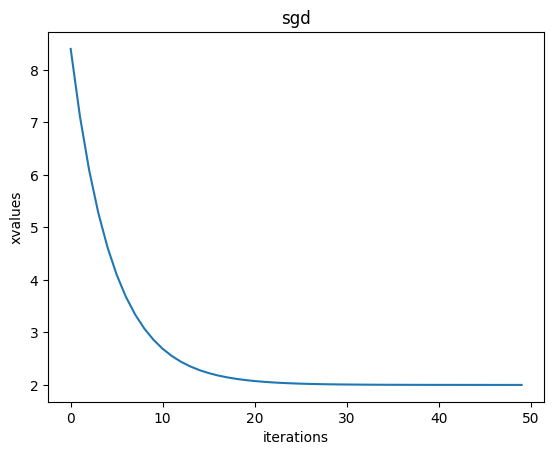

In [1]:
#SGD

import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 4*x + 4
def grad(x):
  return 2*x - 4

lr=0.1
x=10.0
iterations=50
history=[]

for i in range(iterations):
  x = x- lr*grad(x)

  history.append(x)
print(x)
print(f(x))

plt.plot(history)
plt.title("sgd")
plt.xlabel("iterations")
plt.ylabel("xvalues")
plt.show()

In [2]:
#ACCELERATED GD

import numpy as np
import matplotlib.pyplot as plt

lr=0.1
v=0.0
iterations=100
momentum=0.9
x=4.0
clip=5

for i in range(iterations):
  grad = 20*x*np.sin(x) + 10*x**2*np.cos(x)
  grad=np.clip(grad,-clip,clip)
  v= momentum*v - lr*grad
  x=x+v
print(x)
print(x**2*10*np.sin(x))

5.200747257273043
-238.86003967323208


7.804371375789987e-15
8.834235323891926e-08
6.044629098073048e-56


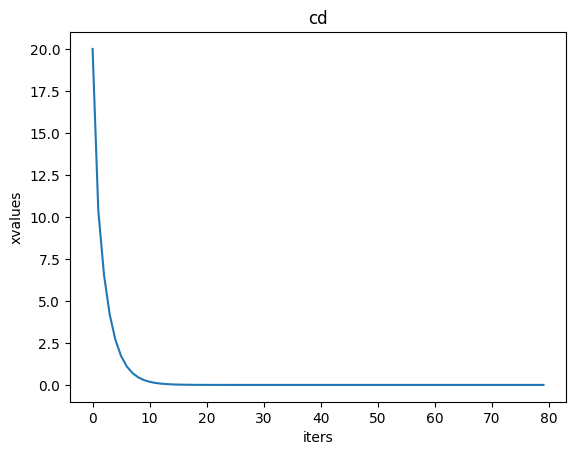

In [3]:
#coordinate gd
import numpy as np
import matplotlib.pyplot as plt

def f(x1,x2):
  return x1**2 + 4*x2**2

lr=0.1
x1=5.0
x2=5.0
iterations=80
history=[]

for i in range(iterations):
  grad_x1= 2*x1
  x1= x1 - lr*grad_x1
  grad_x2 =8*x2
  x2= x2- lr*grad_x2
  history.append(f(x1,x2))

print(f(x1,x2))
print(x1)
print(x2)

plt.plot(history)
plt.title("cd")
plt.xlabel("iters")
plt.ylabel("xvalues")
plt.show()





2.0000178405961586
3.182867303053172e-10


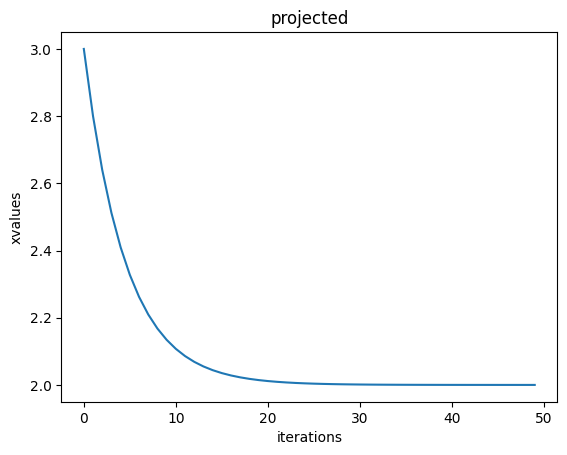

In [4]:
#projected
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 4*x + 4


lr=0.1
x=10.0
history=[]
iterations=50

for i in range(iterations):
  grad=2*x - 4
  x=x - lr*grad
  x=np.clip(x,0,3)
  history.append(x)

print(x)
print(f(x))

plt.plot(history)
plt.title("projected")
plt.xlabel("iterations")
plt.ylabel("xvalues")
plt.show()

2.0340594059405936
0.0011600431330265337


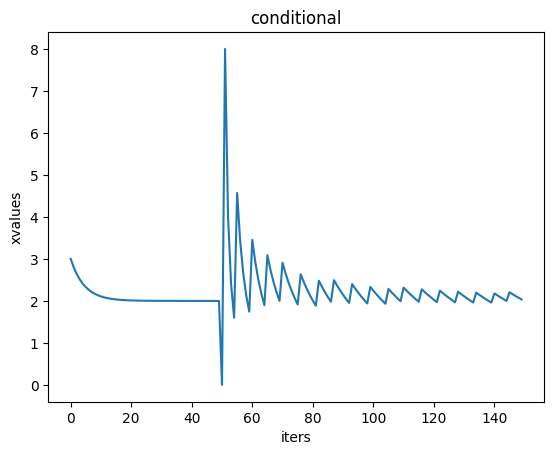

In [5]:
#Condtional

import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 4*x + 4

lr=0.1
x=10
iterations=100
lower=0
upper=12

def linear_minimizer(grad, lower , upper):
  if grad > 0:
    return lower
  else:
    return upper

for i in range(iterations):
  grad=2*x-4
  s=linear_minimizer(grad, lower, upper)
  step=2/(i+2)
  x=x+step*(s-x)
  history.append(x)


print(x)
print(f(x))
plt.plot(history)
plt.title("conditional")
plt.xlabel("iters")
plt.ylabel("xvalues")
plt.show()


In [6]:
import cvxpy as cp

x=cp.Variable()

objective=cp.Minimize( (x-10)**2 + (x-15)**2 + (x-20)**2)
constraints=[
    x<=12,
    x>=0
]
problem=cp.Problem(objective, constraints)
problem.solve()

print(x.value)
print(problem.value)

12.0
77.0


In [7]:
import cvxpy as cp

x=cp.Variable(nonneg=True)
y=cp.Variable(nonneg=True)

objective=cp.Maximize(30*x + 50*y)
constraints=[
    2*x + 4*y <= 100,
    x + 3*y <= 60

]
problem=cp.Problem(objective, constraints)
problem.solve()

print(x.value)
print(y.value)
print(problem.value)


49.99999976580968
1.143898562650166e-07
1499.9999986937833


In [11]:
import cvxpy as cp


w=cp.Variable(2)
a_target=[1, 0.5]
a_interf=[0.3, 0.5]

objective=cp.Minimize(cp.norm(w,2))
constraints=[a_target @ w==1, cp.abs(a_interf @ w)<=0.2]

problem=cp.Problem(objective, constraints)
problem.solve()

print(w.value)
print(problem.value)

[ 1.14285714 -0.28571428]
1.1780301744390755


In [12]:
import cvxpy as cp

x=cp.Variable((2,2), PSD=True)

objective=cp.Minimize(cp.trace(x))

constraints=[x[0,0]==5, x[1,1]==3]
problem=cp.Problem(objective, constraints)
problem.solve()

print(x.value)
print(problem.value)


[[5.00000009 0.        ]
 [0.         3.00000006]]
8.000000152364143


In [14]:
import cvxpy as cp
import numpy as np

m=30
n=10
delta=0.1

x=np.random.randn(m,n)
y=np.random.randn(m)

beta=cp.Variable(n)
t=cp.Variable()

objective=cp.Minimize(t)
constraints=[cp.norm(y[i]-x[i] @ beta) + delta * cp.norm(beta, 2) <= t for i in range(m)]
problem=cp.Problem(objective, constraints)
problem.solve()


print(beta.value)


[ 0.0763329  -0.32681215 -0.13725529 -0.27740038 -0.01517974  0.20059528
  0.38364515 -0.1677362  -0.34722571  0.12109309]
